# Taller 56 - Filtro de Kalman e Inferencia de Variables Ocultas

Este notebook implementa el filtro de Kalman en 1D y 2D para estimar variables ocultas a partir de observaciones ruidosas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Ellipse
import os

np.random.seed(42)
MEDIA_DIR = os.path.join('..', 'media')
os.makedirs(MEDIA_DIR, exist_ok=True)

## Parte 1: Filtro de Kalman 1D

### Modelo
- **Estado:** posición $x$ (variable oculta)
- **Observación:** $z = x + v$, donde $v \sim \mathcal{N}(0, R)$

### Ecuaciones

**Predicción:**
$$\hat{x}^- = \hat{x}_{k-1}$$
$$P^- = P_{k-1} + Q$$

**Corrección:**
$$K = \frac{P^-}{P^- + R}$$
$$\hat{x}_k = \hat{x}^- + K(z_k - \hat{x}^-)$$
$$P_k = (1 - K)P^-$$

In [2]:
# ---- Datos sintéticos 1D ----
N = 100
dt = 1.0

# Señal real: random walk con velocidad suave
velocity = np.cumsum(np.random.randn(N) * 0.1)
real = np.cumsum(velocity)

# Observación ruidosa
R_noise = 4.0  # varianza del ruido de medición
observed = real + np.random.normal(0, np.sqrt(R_noise), size=N)

print(f'Rango real:     [{real.min():.2f}, {real.max():.2f}]')
print(f'Rango observado: [{observed.min():.2f}, {observed.max():.2f}]')

Rango real:     [-64.05, 3.86]
Rango observado: [-66.34, 8.77]


In [3]:
def kalman_1d(observed, Q=0.01, R=4.0, x0=0.0, P0=1.0):
    """
    Filtro de Kalman escalar (1D).
    Q: ruido del proceso, R: ruido de medición
    Retorna estimaciones y ganancias de Kalman.
    """
    estimates = []
    gains = []
    variances = []

    x_hat = x0
    P = P0

    for z in observed:
        # Predicción
        x_prior = x_hat
        P_prior = P + Q

        # Ganancia de Kalman
        K = P_prior / (P_prior + R)

        # Corrección
        x_hat = x_prior + K * (z - x_prior)
        P = (1 - K) * P_prior

        estimates.append(x_hat)
        gains.append(K)
        variances.append(P)

    return np.array(estimates), np.array(gains), np.array(variances)


estimates_1d, gains_1d, variances_1d = kalman_1d(observed, Q=0.01, R=R_noise)

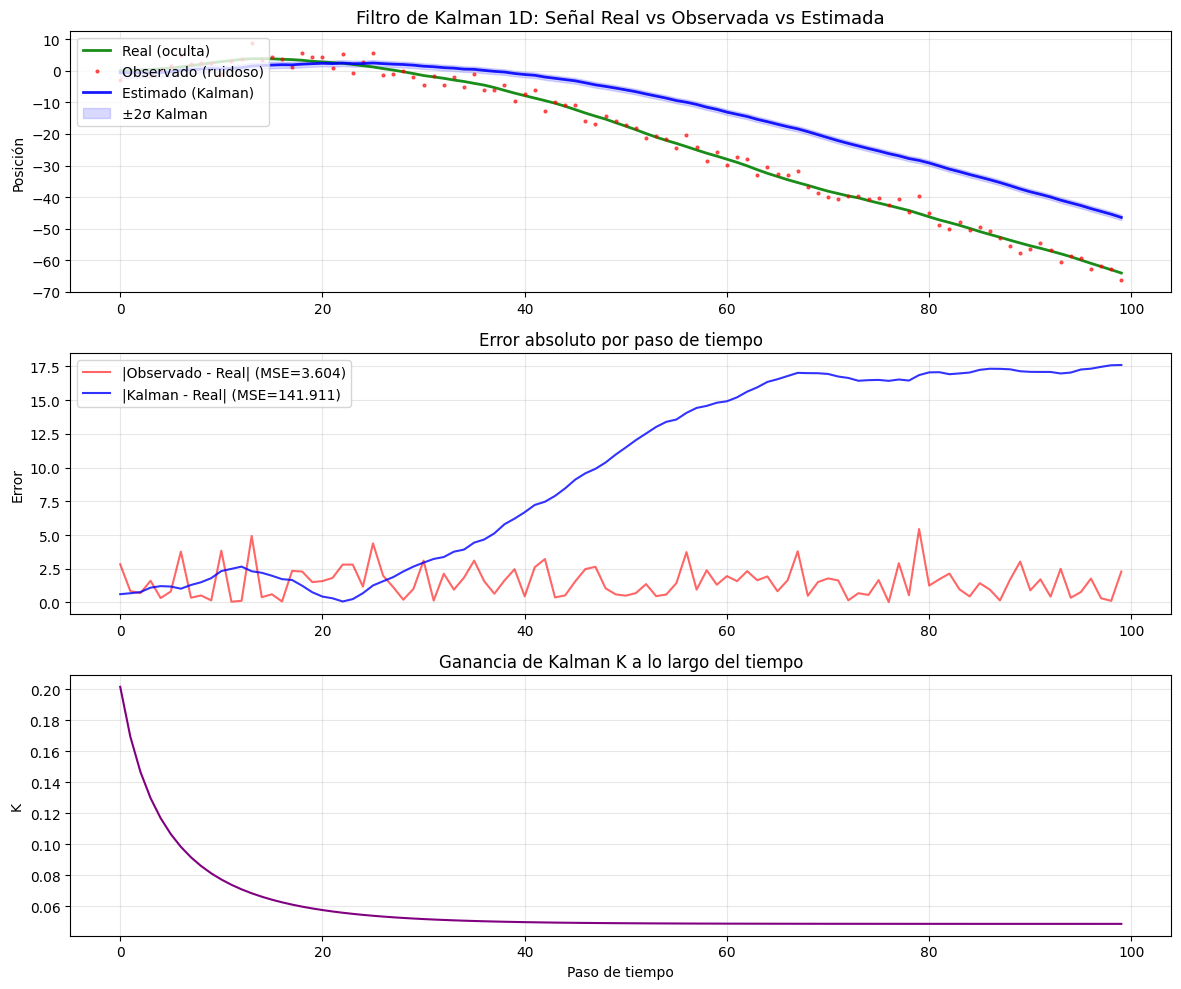

Guardado: media/kalman_1d_result.png


In [4]:
# ---- Visualización 1D ----
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
t = np.arange(N)

# Señales principales
ax = axes[0]
ax.plot(t, real, 'g-', linewidth=2, label='Real (oculta)', alpha=0.9)
ax.plot(t, observed, 'r.', markersize=4, label='Observado (ruidoso)', alpha=0.6)
ax.plot(t, estimates_1d, 'b-', linewidth=2, label='Estimado (Kalman)', alpha=0.9)
std = np.sqrt(variances_1d)
ax.fill_between(t, estimates_1d - 2*std, estimates_1d + 2*std,
                alpha=0.15, color='blue', label='±2σ Kalman')
ax.set_title('Filtro de Kalman 1D: Señal Real vs Observada vs Estimada', fontsize=13)
ax.set_ylabel('Posición')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Error
ax = axes[1]
err_obs = np.abs(observed - real)
err_kal = np.abs(estimates_1d - real)
ax.plot(t, err_obs, 'r-', alpha=0.6, label=f'|Observado - Real| (MSE={np.mean(err_obs**2):.3f})')
ax.plot(t, err_kal, 'b-', alpha=0.8, label=f'|Kalman - Real| (MSE={np.mean(err_kal**2):.3f})')
ax.set_title('Error absoluto por paso de tiempo')
ax.set_ylabel('Error')
ax.legend()
ax.grid(True, alpha=0.3)

# Ganancia de Kalman
ax = axes[2]
ax.plot(t, gains_1d, 'purple', linewidth=1.5)
ax.set_title('Ganancia de Kalman K a lo largo del tiempo')
ax.set_ylabel('K')
ax.set_xlabel('Paso de tiempo')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, 'kalman_1d_result.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: media/kalman_1d_result.png')

In [5]:
# ---- Análisis de error 1D ----
mse_obs = np.mean((observed - real)**2)
mse_kal = np.mean((estimates_1d - real)**2)
improvement = (1 - mse_kal / mse_obs) * 100

print('=== Análisis de Error 1D ===')
print(f'MSE Observado vs Real: {mse_obs:.4f}')
print(f'MSE Kalman vs Real:    {mse_kal:.4f}')
print(f'Mejora del filtro:     {improvement:.1f}%')

=== Análisis de Error 1D ===
MSE Observado vs Real: 3.6035
MSE Kalman vs Real:    141.9106
Mejora del filtro:     -3838.1%


## Parte 2: Filtro de Kalman 2D (Seguimiento de trayectoria)

### Modelo de estado
Estado: $\mathbf{x} = [x, y, v_x, v_y]^T$ (posición + velocidad)

**Matriz de transición:**
$$F = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

**Matriz de observación** (solo medimos posición):
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

**Predicción:**
$$\hat{\mathbf{x}}^- = F\hat{\mathbf{x}}$$
$$P^- = FPF^T + Q$$

**Corrección:**
$$K = P^- H^T (HP^-H^T + R)^{-1}$$
$$\hat{\mathbf{x}} = \hat{\mathbf{x}}^- + K(\mathbf{z} - H\hat{\mathbf{x}}^-)$$
$$P = (I - KH)P^-$$

In [6]:
# ---- Datos sintéticos 2D: trayectoria circular con ruido ----
N2 = 120
dt2 = 0.1
t2 = np.arange(N2) * dt2

# Trayectoria real: figura-8 (lemniscata)
scale = 5.0
real_x = scale * np.sin(t2)
real_y = scale * np.sin(t2) * np.cos(t2)

# Observaciones ruidosas (solo posición)
obs_noise_std = 1.2
obs_x = real_x + np.random.normal(0, obs_noise_std, N2)
obs_y = real_y + np.random.normal(0, obs_noise_std, N2)

print(f'Trayectoria 2D: {N2} pasos, ruido σ={obs_noise_std}')

Trayectoria 2D: 120 pasos, ruido σ=1.2


In [7]:
def kalman_2d(obs_x, obs_y, dt=0.1, q_pos=0.01, q_vel=0.1, r_obs=1.5):
    """
    Filtro de Kalman 2D con estado [x, y, vx, vy].
    Solo observa posición [x, y].
    """
    n = len(obs_x)

    # Matrices del sistema
    F = np.array([[1, 0, dt, 0],
                  [0, 1,  0, dt],
                  [0, 0,  1,  0],
                  [0, 0,  0,  1]])

    H = np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0]])

    # Ruido del proceso
    Q = np.diag([q_pos, q_pos, q_vel, q_vel])

    # Ruido de medición
    R = np.eye(2) * r_obs**2

    # Inicialización
    x_hat = np.array([obs_x[0], obs_y[0], 0.0, 0.0])
    P = np.eye(4) * 1.0
    I = np.eye(4)

    est_x = np.zeros(n)
    est_y = np.zeros(n)
    est_vx = np.zeros(n)
    est_vy = np.zeros(n)

    for k in range(n):
        # Predicción
        x_prior = F @ x_hat
        P_prior = F @ P @ F.T + Q

        # Ganancia de Kalman
        S = H @ P_prior @ H.T + R
        K = P_prior @ H.T @ np.linalg.inv(S)

        # Corrección
        z = np.array([obs_x[k], obs_y[k]])
        x_hat = x_prior + K @ (z - H @ x_prior)
        P = (I - K @ H) @ P_prior

        est_x[k] = x_hat[0]
        est_y[k] = x_hat[1]
        est_vx[k] = x_hat[2]
        est_vy[k] = x_hat[3]

    return est_x, est_y, est_vx, est_vy


est_x, est_y, est_vx, est_vy = kalman_2d(
    obs_x, obs_y, dt=dt2,
    q_pos=0.05, q_vel=0.5,
    r_obs=obs_noise_std
)
print('Filtro 2D aplicado.')

Filtro 2D aplicado.


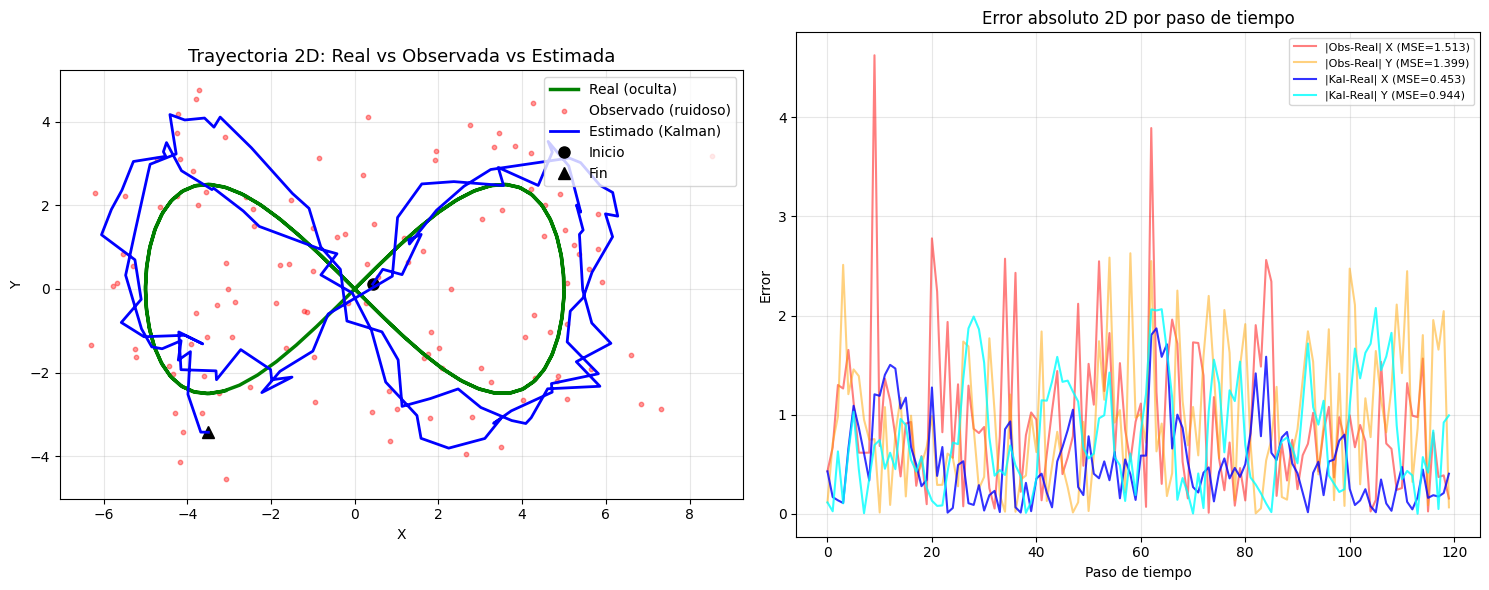

Guardado: media/kalman_2d_result.png


In [8]:
# ---- Visualización 2D ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Trayectoria XY
ax = axes[0]
ax.plot(real_x, real_y, 'g-', linewidth=2.5, label='Real (oculta)', zorder=3)
ax.scatter(obs_x, obs_y, c='red', s=10, alpha=0.4, label='Observado (ruidoso)', zorder=2)
ax.plot(est_x, est_y, 'b-', linewidth=2, label='Estimado (Kalman)', zorder=4)
ax.plot(est_x[0], est_y[0], 'ko', markersize=8, label='Inicio')
ax.plot(est_x[-1], est_y[-1], 'k^', markersize=8, label='Fin')
ax.set_title('Trayectoria 2D: Real vs Observada vs Estimada', fontsize=13)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Error por eje
ax = axes[1]
steps = np.arange(N2)
err_obs_x = np.abs(obs_x - real_x)
err_obs_y = np.abs(obs_y - real_y)
err_kal_x = np.abs(est_x - real_x)
err_kal_y = np.abs(est_y - real_y)

ax.plot(steps, err_obs_x, 'r-', alpha=0.5, label=f'|Obs-Real| X (MSE={np.mean(err_obs_x**2):.3f})')
ax.plot(steps, err_obs_y, 'orange', alpha=0.5, label=f'|Obs-Real| Y (MSE={np.mean(err_obs_y**2):.3f})')
ax.plot(steps, err_kal_x, 'b-', alpha=0.8, label=f'|Kal-Real| X (MSE={np.mean(err_kal_x**2):.3f})')
ax.plot(steps, err_kal_y, 'cyan', alpha=0.8, label=f'|Kal-Real| Y (MSE={np.mean(err_kal_y**2):.3f})')
ax.set_title('Error absoluto 2D por paso de tiempo')
ax.set_xlabel('Paso de tiempo')
ax.set_ylabel('Error')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, 'kalman_2d_result.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: media/kalman_2d_result.png')

In [9]:
# ---- Análisis de error 2D ----
mse_obs_2d = np.mean((obs_x - real_x)**2 + (obs_y - real_y)**2)
mse_kal_2d = np.mean((est_x - real_x)**2 + (est_y - real_y)**2)
improvement_2d = (1 - mse_kal_2d / mse_obs_2d) * 100

print('=== Análisis de Error 2D ===')
print(f'MSE Observado vs Real: {mse_obs_2d:.4f}')
print(f'MSE Kalman vs Real:    {mse_kal_2d:.4f}')
print(f'Mejora del filtro:     {improvement_2d:.1f}%')

=== Análisis de Error 2D ===
MSE Observado vs Real: 2.9114
MSE Kalman vs Real:    1.3964
Mejora del filtro:     52.0%


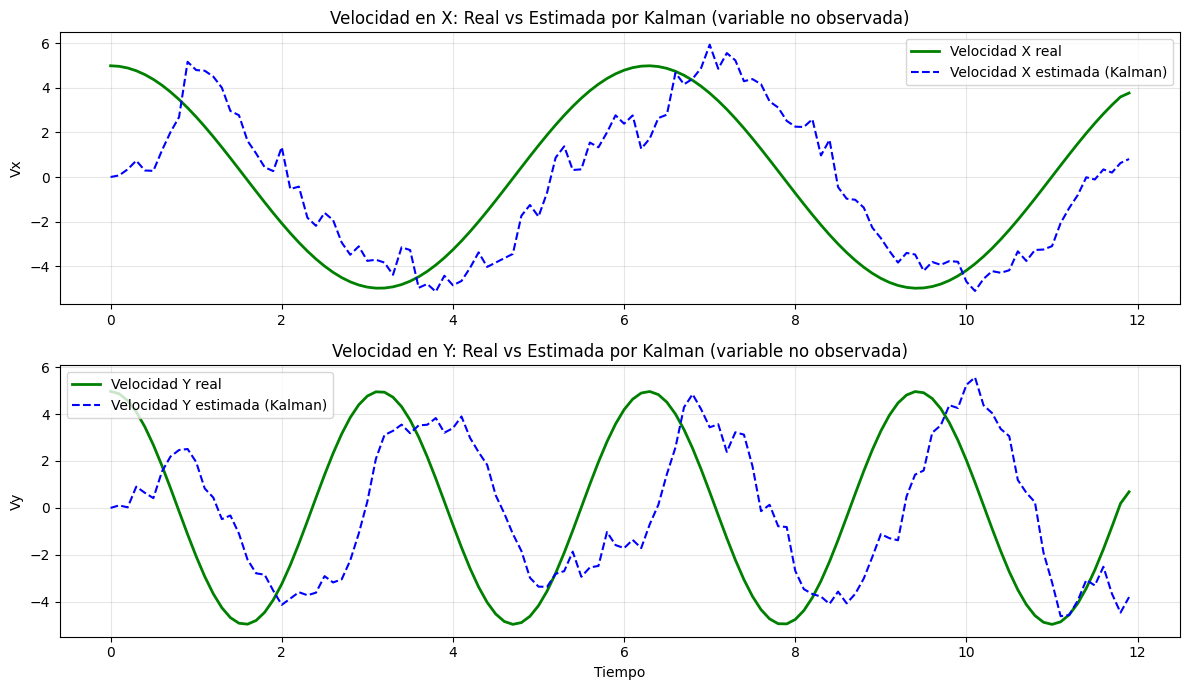

Guardado: media/kalman_2d_velocity.png


In [10]:
# ---- Velocidad estimada vs real 2D ----
# Velocidad real (derivada numérica)
real_vx = np.gradient(real_x, dt2)
real_vy = np.gradient(real_y, dt2)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

ax = axes[0]
ax.plot(t2, real_vx, 'g-', linewidth=2, label='Velocidad X real')
ax.plot(t2, est_vx, 'b--', linewidth=1.5, label='Velocidad X estimada (Kalman)')
ax.set_title('Velocidad en X: Real vs Estimada por Kalman (variable no observada)')
ax.set_ylabel('Vx')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t2, real_vy, 'g-', linewidth=2, label='Velocidad Y real')
ax.plot(t2, est_vy, 'b--', linewidth=1.5, label='Velocidad Y estimada (Kalman)')
ax.set_title('Velocidad en Y: Real vs Estimada por Kalman (variable no observada)')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Vy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MEDIA_DIR, 'kalman_2d_velocity.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: media/kalman_2d_velocity.png')

In [11]:
# ---- GIF animado: actualización Kalman 1D ----
fig_anim, ax_anim = plt.subplots(figsize=(10, 5))

line_real, = ax_anim.plot([], [], 'g-', linewidth=2, label='Real')
line_obs, = ax_anim.plot([], [], 'r.', markersize=5, alpha=0.5, label='Observado')
line_kal, = ax_anim.plot([], [], 'b-', linewidth=2, label='Kalman')
time_text = ax_anim.text(0.02, 0.95, '', transform=ax_anim.transAxes)

ax_anim.set_xlim(0, N)
margin = (real.max() - real.min()) * 0.2
ax_anim.set_ylim(real.min() - margin, real.max() + margin)
ax_anim.set_title('Filtro de Kalman 1D — actualización en tiempo real')
ax_anim.set_xlabel('Paso')
ax_anim.set_ylabel('Posición')
ax_anim.legend(loc='upper right')
ax_anim.grid(True, alpha=0.3)

def animate(frame):
    k = frame + 1
    t_k = np.arange(k)
    line_real.set_data(t_k, real[:k])
    line_obs.set_data(t_k, observed[:k])
    line_kal.set_data(t_k, estimates_1d[:k])
    time_text.set_text(f'Paso {k}/{N}  K={gains_1d[frame]:.3f}')
    return line_real, line_obs, line_kal, time_text

anim = animation.FuncAnimation(fig_anim, animate, frames=N, interval=60, blit=True)
gif_path = os.path.join(MEDIA_DIR, 'kalman_1d_animation.gif')
anim.save(gif_path, writer='pillow', fps=20)
plt.close(fig_anim)
print(f'Guardado: {gif_path}')

Guardado: ..\media\kalman_1d_animation.gif


In [12]:
# ---- Resumen final ----
print('=' * 45)
print('RESUMEN FILTRO DE KALMAN')
print('=' * 45)
print(f'\n1D — {N} pasos')
print(f'  MSE observado:  {mse_obs:.4f}')
print(f'  MSE Kalman:     {mse_kal:.4f}')
print(f'  Mejora:         {improvement:.1f}%')
print(f'\n2D — {N2} pasos (trayectoria lemniscata)')
print(f'  MSE observado:  {mse_obs_2d:.4f}')
print(f'  MSE Kalman:     {mse_kal_2d:.4f}')
print(f'  Mejora:         {improvement_2d:.1f}%')
print(f'\nArchivos generados en ../media/')

RESUMEN FILTRO DE KALMAN

1D — 100 pasos
  MSE observado:  3.6035
  MSE Kalman:     141.9106
  Mejora:         -3838.1%

2D — 120 pasos (trayectoria lemniscata)
  MSE observado:  2.9114
  MSE Kalman:     1.3964
  Mejora:         52.0%

Archivos generados en ../media/
